<a href="https://colab.research.google.com/github/lilianabs/ml-algorithms-from-scratch/blob/main/logistic_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

## Dataset

In [40]:

# Generate a synthetic binary classification dataset
X, y = make_classification(
    n_samples=100,      # Number of data points
    n_features=2,       # Number of features (x and y for plotting)
    n_redundant=0,      # Mandatory for 2-feature datasets
    n_informative=2,    # Both features help distinguish the classes
    n_clusters_per_class=1,
    class_sep=1.5,      # Larger number = further apart (easier)
    random_state=42     # Seed for reproducibility
)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

print("\nFirst 5 rows of features (X):")
print(X[:5])

print("\nFirst 5 target values (y):")
print(y[:5])

Shape of features (X): (100, 2)
Shape of target (y): (100,)

First 5 rows of features (X):
[[ 1.72831184 -1.25717844]
 [ 1.19840909 -1.88029525]
 [ 3.04881729  3.00225822]
 [ 1.07357881 -1.85297943]
 [ 1.08590018 -1.83745666]]

First 5 target values (y):
[0 0 1 0 0]


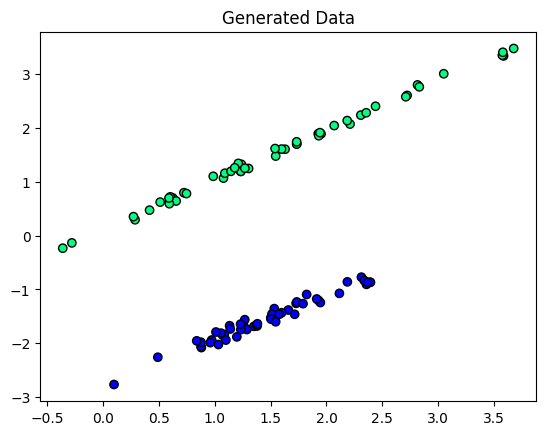

In [41]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')
plt.title("Generated Data")
plt.show()

## Logistic regression implementation (only functions)

In [42]:
# Initialize weights and bias
n_samples = X.shape[0] # Number of samples
n_features = X.shape[1] # Number of features
w = np.zeros((n_features, 1)) # Weights should be initialized based on the number of features
b = 0

In [43]:
n_iterations = 1000
learning_rate = 0.01

In [44]:
# Sigmoid function
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

sigmoid(0.8)

np.float64(0.6899744811276125)

In [45]:
# Prediction function
def predict(X):
  return np.where(X >= 0.5, 1, 0)

In [46]:
# Gradient descent
costs = []

for i in range(n_iterations):
  # Forward pass
  Z = np.dot(X, w) + b
  A = sigmoid(Z)

  # Calculate Cost (using epsilon to avoid log(0) which is undefined)
  epsilon = 1e-15
  A_clipped = np.clip(A, epsilon, 1 - epsilon) # Clip A for cost calculation
  cost = - (1 / n_samples) * np.sum(y.reshape(A.shape) * np.log(A_clipped) + (1 - y.reshape(A.shape)) * np.log(1 - A_clipped))
  costs.append(cost)

  # Gradient calculations
  error = A - y.reshape(A.shape)
  dw = (1 / n_samples) * np.dot(X.T, error)
  db = (1 / n_samples) * np.sum(error)

  # Update weights and bias
  w = w - (learning_rate * dw)
  b = b - (learning_rate * db)

  if i % 100 == 0: # Print less frequently due to more iterations
     print(f"Cost after iteration {i}: {cost}")

Cost after iteration 0: 0.6931471805599453
Cost after iteration 100: 0.36078111037758415
Cost after iteration 200: 0.24832525137162756
Cost after iteration 300: 0.1935284699675016
Cost after iteration 400: 0.16098607994362943
Cost after iteration 500: 0.13925571053783078
Cost after iteration 600: 0.1235958625444727
Cost after iteration 700: 0.11169589379455883
Cost after iteration 800: 0.10229493481437492
Cost after iteration 900: 0.09464535286033306


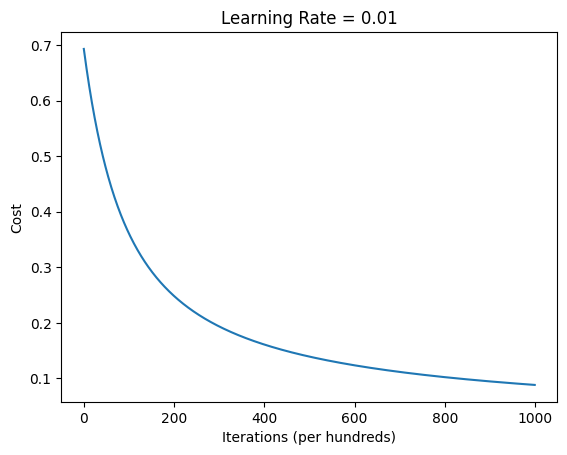

In [47]:
plt.plot(costs)
plt.ylabel('Cost')
plt.xlabel('Iterations (per hundreds)')
plt.title('Learning Rate = ' + str(learning_rate))
plt.show()

In [48]:
# Get accuracy

## Logistic regression implementation (Python class)

In [49]:
def cost(A, y, n_samples):
  # Calculate Cost (using epsilon to avoid log(0) which is undefined)
  epsilon = 1e-15
  A_clipped = np.clip(A, epsilon, 1 - epsilon) # Clip A for cost calculation
  cost = - (1 / n_samples) * np.sum(y.reshape(A.shape) * np.log(A_clipped) + (1 - y.reshape(A.shape)) * np.log(1 - A_clipped))
  return cost

def sigmoid(z):
  return 1 / (1 + np.exp(-z))

class LogisticRegressionImp:
  def __init__(self, learning_rate=0.01, n_iterations=1000):
    self.learning_rate = learning_rate
    self.n_iterations = n_iterations
    self.weights = None
    self.bias = None

  def _predict(self, X):
      Z = np.dot(X, self.weights) + self.bias
      A = sigmoid(Z)
      return A

  def fit(self, X, y):
    # Initialize weights and bias
    n_samples = X.shape[0] # Number of samples
    n_features = X.shape[1] # Number of features
    self.weights = np.zeros((n_features, 1)) # Weights should be initialized based on the number of features
    self.bias = 0

    cost_iterations = []
    for i in range(self.n_iterations):
      # Compute predictions
      A = self._predict(X)

      # Calculate Cost (using epsilon to avoid log(0) which is undefined)
      epsilon = 1e-15
      A_clipped = np.clip(A, epsilon, 1 - epsilon) # Clip A for cost calculation
      cost_val = - (1 / n_samples) * np.sum(y.reshape(A.shape) * np.log(A_clipped) + (1 - y.reshape(A.shape)) * np.log(1 - A_clipped))
      cost_iterations.append(cost_val)

      # Compute gradients
      error = A - y.reshape(A.shape)
      dw = (1 / n_samples) * np.dot(X.T, error)
      db = (1 / n_samples) * np.sum(error)

      # Update parameters and bias
      self.weights = self.weights - (self.learning_rate * dw)
      self.bias = self.bias - (self.learning_rate * db)

      if i % 100 == 0: # Print less frequently due to more iterations
         print(f"Cost after iteration {i}: {cost_iterations[-1]}") # Access the last added cost

  def predict(self, X):
    A = self._predict(X)
    return np.where(A >= 0.5, 1, 0)

## Test implementation

In [50]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=1
)

In [57]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [60]:
lr_imp = LogisticRegressionImp(learning_rate=0.01, n_iterations=2000)
lr_imp.fit(X_train, y_train)
y_pred_imp = lr_imp.predict(X_test)

Cost after iteration 0: 0.6931471805599454
Cost after iteration 100: 0.35047968747687364
Cost after iteration 200: 0.23774502709834386
Cost after iteration 300: 0.1833037217664471
Cost after iteration 400: 0.15116071317787308
Cost after iteration 500: 0.129810497069104
Cost after iteration 600: 0.11450437679822634
Cost after iteration 700: 0.10293281970001844
Cost after iteration 800: 0.09383736078981046
Cost after iteration 900: 0.08647277754885418
Cost after iteration 1000: 0.08036887396610395
Cost after iteration 1100: 0.07521379422732954
Cost after iteration 1200: 0.07079219692434224
Cost after iteration 1300: 0.06695036761462347
Cost after iteration 1400: 0.06357548900626953
Cost after iteration 1500: 0.060582780771017974
Cost after iteration 1600: 0.0579072244914461
Cost after iteration 1700: 0.05549806928113454
Cost after iteration 1800: 0.053315083007271016
Cost after iteration 1900: 0.05132593279641034


In [61]:
from sklearn.metrics import accuracy_score

accuracy_sklearn = accuracy_score(y_test, y_pred)
accuracy_custom = accuracy_score(y_test, y_pred_imp)

print(f"Accuracy (scikit-learn Logistic Regression): {accuracy_sklearn:.4f}")
print(f"Accuracy (Custom Logistic RegressionImp): {accuracy_custom:.4f}")

Accuracy (scikit-learn Logistic Regression): 1.0000
Accuracy (Custom Logistic RegressionImp): 0.9500
